# Heart Disease Detection — Champion Model: XGBoost Classifier (CRISP-DM Stage 2)

This notebook implements a **Tree-based Ensemble model using XGBoost** as a candidate champion model for heart disease prediction.

## Stage 2 Objectives
- Build a scikit-learn **Pipeline** (scaling + XGBClassifier) to prevent data leakage
- Handle class imbalance via `scale_pos_weight`
- Tune hyperparameters with **RandomizedSearchCV** (50 iterations, 5-fold CV)
- Output **probability scores** (0.0–1.0) and apply a custom **decision threshold**
- Evaluate with Classification Report, Confusion Matrix, ROC-AUC
- Perform **failure analysis** (top 10 most confident failures)
- Produce comparison metrics for group integration

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
    accuracy_score,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")
print(f"Random State: {RANDOM_STATE}")

Libraries imported successfully!
Random State: 42


## 2. Load Data from Data Preparation Stage

In [2]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test  shape: {y_test.shape}")

X_train shape: (352827, 76)
X_test  shape: (88414, 76)
y_train shape: (352827,)
y_test  shape: (88414,)


## 3. Encode Target Variable & Check Class Imbalance

In [3]:
# Encode target: "Yes" -> 1, "No" -> 0
le = LabelEncoder()
le.fit(["No", "Yes"])
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"\nTraining set target distribution:")
unique, counts = np.unique(y_train_enc, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {le.inverse_transform([label])[0]} ({label}): {count} ({count/len(y_train_enc)*100:.2f}%)")

# Calculate scale_pos_weight for imbalance handling
neg_count = np.sum(y_train_enc == 0)
pos_count = np.sum(y_train_enc == 1)
scale_pos_weight = neg_count / pos_count
print(f"\nClass imbalance ratio (No:Yes): {scale_pos_weight:.2f}:1")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

Label mapping: {np.str_('No'): np.int64(0), np.str_('Yes'): np.int64(1)}

Training set target distribution:
  No (0): 332781 (94.32%)
  Yes (1): 20046 (5.68%)

Class imbalance ratio (No:Yes): 16.60:1
scale_pos_weight = 16.60


## 4. Build Scikit-learn Pipeline

The pipeline bundles a `StandardScaler` and the `XGBClassifier` together to prevent data leakage — scaling statistics are computed only from training folds during cross-validation.

In [4]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=2,
    )),
])

print("Pipeline created:")
print(pipeline)

Pipeline created:
Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
      

## 5. Hyperparameter Tuning with RandomizedSearchCV

We tune `n_estimators`, `max_depth`, and `learning_rate` over **50 iterations** with **5-fold stratified CV**.

In [5]:
param_distributions = {
    "xgb__n_estimators": [100, 200, 300, 400, 500],
    "xgb__max_depth": [3, 4, 5, 6, 7, 8, 10],
    "xgb__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=2,
    verbose=1,
    return_train_score=True,
)

print("Starting RandomizedSearchCV (50 iterations, 5-fold CV)...")
random_search.fit(X_train, y_train_enc)
print("\nSearch complete!")

Starting RandomizedSearchCV (50 iterations, 5-fold CV)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\favia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [21:02:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Search complete!


In [6]:
print("Best hyperparameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV F1-score: {random_search.best_score_:.4f}")

# Extract best model from the search
best_pipeline = random_search.best_estimator_

Best hyperparameters found:
  xgb__n_estimators: 400
  xgb__max_depth: 10
  xgb__learning_rate: 0.03

Best CV F1-score: 0.2735


## 6. Probability Output & Custom Decision Threshold

Instead of the default 0.5 threshold, we apply a **custom threshold of 0.65** as an actionable business policy — a higher threshold means we only flag patients as at-risk when the model is more confident, reducing false positives in a screening context.

In [7]:
# Predict probabilities on the test set
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print("Probability score summary (P(HeartAttack=Yes)):")
print(f"  Min:    {y_proba.min():.4f}")
print(f"  Max:    {y_proba.max():.4f}")
print(f"  Mean:   {y_proba.mean():.4f}")
print(f"  Median: {np.median(y_proba):.4f}")

# Apply custom decision threshold
THRESHOLD = 0.65
y_pred_custom = (y_proba >= THRESHOLD).astype(int)

# Also get default threshold predictions for comparison
y_pred_default = (y_proba >= 0.5).astype(int)

print(f"\nPredictions with default threshold (0.50):")
print(f"  Predicted Yes: {np.sum(y_pred_default == 1)}, Predicted No: {np.sum(y_pred_default == 0)}")
print(f"\nPredictions with custom threshold ({THRESHOLD}):")
print(f"  Predicted Yes: {np.sum(y_pred_custom == 1)}, Predicted No: {np.sum(y_pred_custom == 0)}")

Probability score summary (P(HeartAttack=Yes)):
  Min:    0.0002
  Max:    0.9920
  Mean:   0.2693
  Median: 0.1795

Predictions with default threshold (0.50):
  Predicted Yes: 19196, Predicted No: 69218

Predictions with custom threshold (0.65):
  Predicted Yes: 10513, Predicted No: 77901


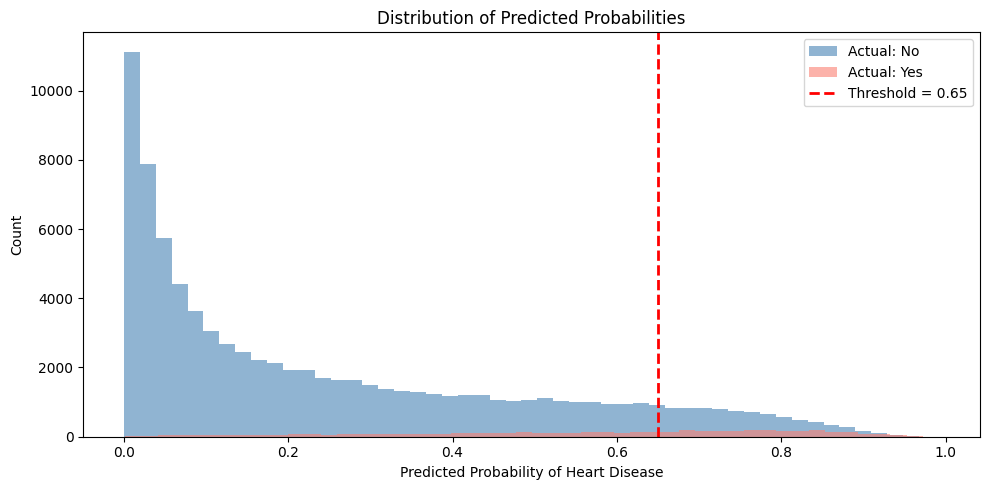

In [8]:
# Visualise the probability distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_proba[y_test_enc == 0], bins=50, alpha=0.6, label="Actual: No", color="steelblue")
ax.hist(y_proba[y_test_enc == 1], bins=50, alpha=0.6, label="Actual: Yes", color="salmon")
ax.axvline(THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Threshold = {THRESHOLD}")
ax.set_xlabel("Predicted Probability of Heart Disease")
ax.set_ylabel("Count")
ax.set_title("Distribution of Predicted Probabilities")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Evaluation & Failure Analysis

### 7.1 Classification Report (Custom Threshold)

In [9]:
target_names = ["No Heart Disease (0)", "Heart Disease (1)"]
print(f"Classification Report (Threshold = {THRESHOLD})")
print("=" * 60)
print(classification_report(y_test_enc, y_pred_custom, target_names=target_names))

Classification Report (Threshold = 0.65)
                      precision    recall  f1-score   support

No Heart Disease (0)       0.96      0.90      0.93     83392
   Heart Disease (1)       0.22      0.45      0.29      5022

            accuracy                           0.88     88414
           macro avg       0.59      0.68      0.61     88414
        weighted avg       0.92      0.88      0.90     88414



### 7.2 Confusion Matrix

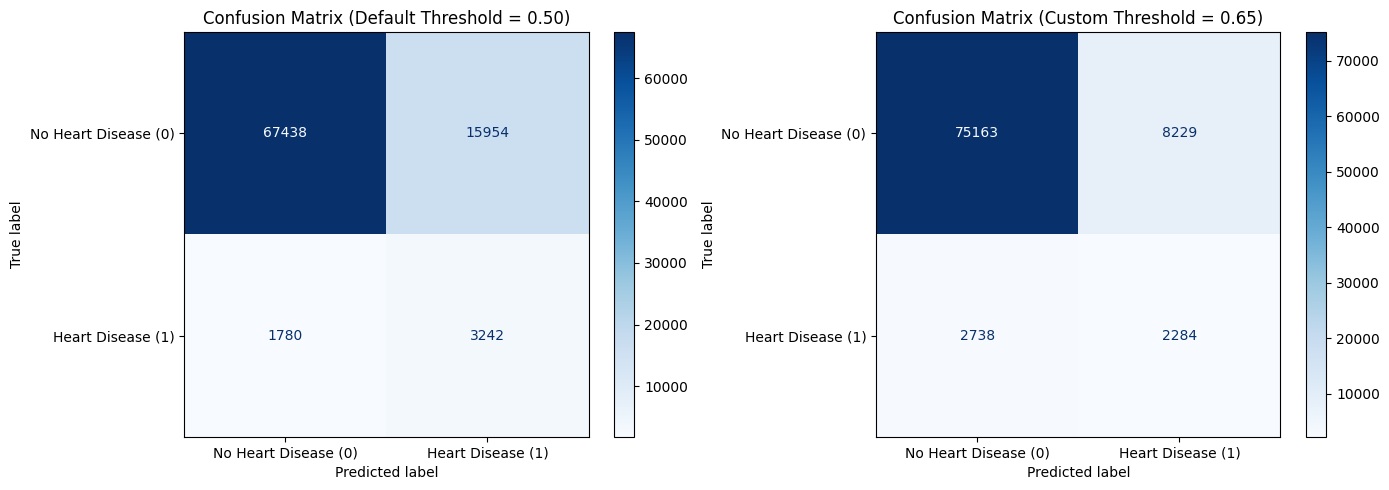

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default threshold
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, y_pred_default,
    display_labels=target_names,
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix (Default Threshold = 0.50)")

# Custom threshold
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, y_pred_custom,
    display_labels=target_names,
    cmap="Blues",
    ax=axes[1],
)
axes[1].set_title(f"Confusion Matrix (Custom Threshold = {THRESHOLD})")

plt.tight_layout()
plt.show()

### 7.3 ROC-AUC Score & Curve

ROC-AUC Score: 0.8213


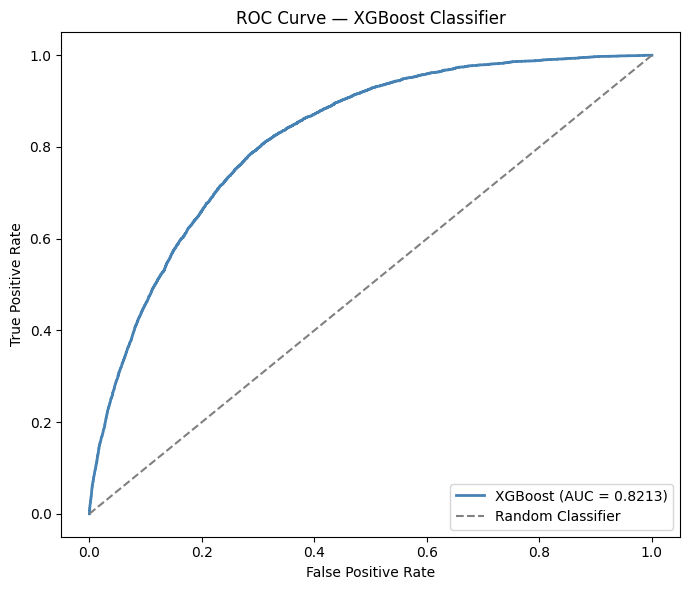

In [11]:
roc_auc = roc_auc_score(y_test_enc, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test_enc, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"XGBoost (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — XGBoost Classifier")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 7.4 Failure Analysis — Top 10 Most Confident Failures

These are cases where the model was **most confidently wrong**:
- **False Positives:** high predicted probability, but actual label is No (0)
- **False Negatives:** low predicted probability, but actual label is Yes (1)

Analysing these helps us understand the model's mechanical weaknesses.

In [12]:
# Build a failure analysis dataframe
failure_df = pd.DataFrame({
    "actual": y_test_enc,
    "predicted_prob": y_proba,
    "predicted_label": y_pred_custom,
})
failure_df["error"] = failure_df["actual"] != failure_df["predicted_label"]
failure_df["confidence"] = np.abs(failure_df["predicted_prob"] - 0.5)

# Filter to errors only, sorted by confidence (most confident mistakes first)
errors = failure_df[failure_df["error"]].sort_values("confidence", ascending=False)

print(f"Total misclassifications (threshold={THRESHOLD}): {len(errors)} / {len(failure_df)} ({len(errors)/len(failure_df)*100:.2f}%)")
print(f"\n{'='*80}")
print("TOP 10 MOST CONFIDENT FAILURES")
print(f"{'='*80}")

top_10 = errors.head(10).copy()
top_10["actual_label"] = le.inverse_transform(top_10["actual"])
top_10["failure_type"] = top_10.apply(
    lambda r: "FALSE POSITIVE (predicted Yes, actual No)" if r["actual"] == 0
    else "FALSE NEGATIVE (predicted No, actual Yes)",
    axis=1
)

for i, (idx, row) in enumerate(top_10.iterrows(), 1):
    print(f"\n#{i} | Test index: {idx}")
    print(f"   Predicted probability: {row['predicted_prob']:.4f}")
    print(f"   Actual label:          {row['actual_label']}")
    print(f"   Type:                  {row['failure_type']}")

Total misclassifications (threshold=0.65): 10967 / 88414 (12.40%)

TOP 10 MOST CONFIDENT FAILURES

#1 | Test index: 32919
   Predicted probability: 0.0017
   Actual label:          Yes
   Type:                  FALSE NEGATIVE (predicted No, actual Yes)

#2 | Test index: 60304
   Predicted probability: 0.0038
   Actual label:          Yes
   Type:                  FALSE NEGATIVE (predicted No, actual Yes)

#3 | Test index: 39441
   Predicted probability: 0.0041
   Actual label:          Yes
   Type:                  FALSE NEGATIVE (predicted No, actual Yes)

#4 | Test index: 51681
   Predicted probability: 0.0047
   Actual label:          Yes
   Type:                  FALSE NEGATIVE (predicted No, actual Yes)

#5 | Test index: 67564
   Predicted probability: 0.0048
   Actual label:          Yes
   Type:                  FALSE NEGATIVE (predicted No, actual Yes)

#6 | Test index: 48885
   Predicted probability: 0.0067
   Actual label:          Yes
   Type:                  FALSE NEGATIVE

In [13]:
# Examine feature values of the top 10 failures
top_10_indices = top_10.index.tolist()
top_10_features = X_test.iloc[top_10_indices].copy()
top_10_features.insert(0, "actual_label", top_10["actual_label"].values)
top_10_features.insert(1, "predicted_prob", top_10["predicted_prob"].values)
top_10_features.insert(2, "failure_type", top_10["failure_type"].values)

print("Feature values for top 10 most confident failures:")
top_10_features.T

Feature values for top 10 most confident failures:


,32919,60304,39441,51681,67564,48885,50597,63672,66324,78822
actual_label,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
predicted_prob,0.001749,0.003763,0.004114,0.004674,0.004824,0.006709,0.007599,0.008301,0.008843,0.00897
failure_type,"FALSE NEGATIVE (predicted No, actual Yes)","FALSE NEGATIVE (predicted No, actual Yes)","FALSE NEGATIVE (predicted No, actual Yes)","FALSE NEGATIVE (predicted No, actual Yes)","FALSE NEGATIVE (predicted No, actual Yes)","FALSE NEGATIVE (predicted No, actual Yes)","FALSE NEGATIVE (predicted No, actual Yes)","FALSE NEGATIVE (predicted No, actual Yes)","FALSE NEGATIVE (predicted No, actual Yes)","FALSE NEGATIVE (predicted No, actual Yes)"
Sex,0,1,1,1,1,1,1,1,0,1
PhysicalHealthDays,0.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...
"TetanusLast10Tdap_Yes, received tetanus shot but not sure what type",False,True,False,False,False,True,False,False,False,False
"TetanusLast10Tdap_Yes, received tetanus shot, but not Tdap",False,False,False,False,False,False,False,False,False,False
CovidPos_No,True,True,True,True,True,True,True,False,True,True
CovidPos_Tested positive using home test without a health professional,False,False,False,False,False,False,False,False,False,False


## 8. Feature Importance

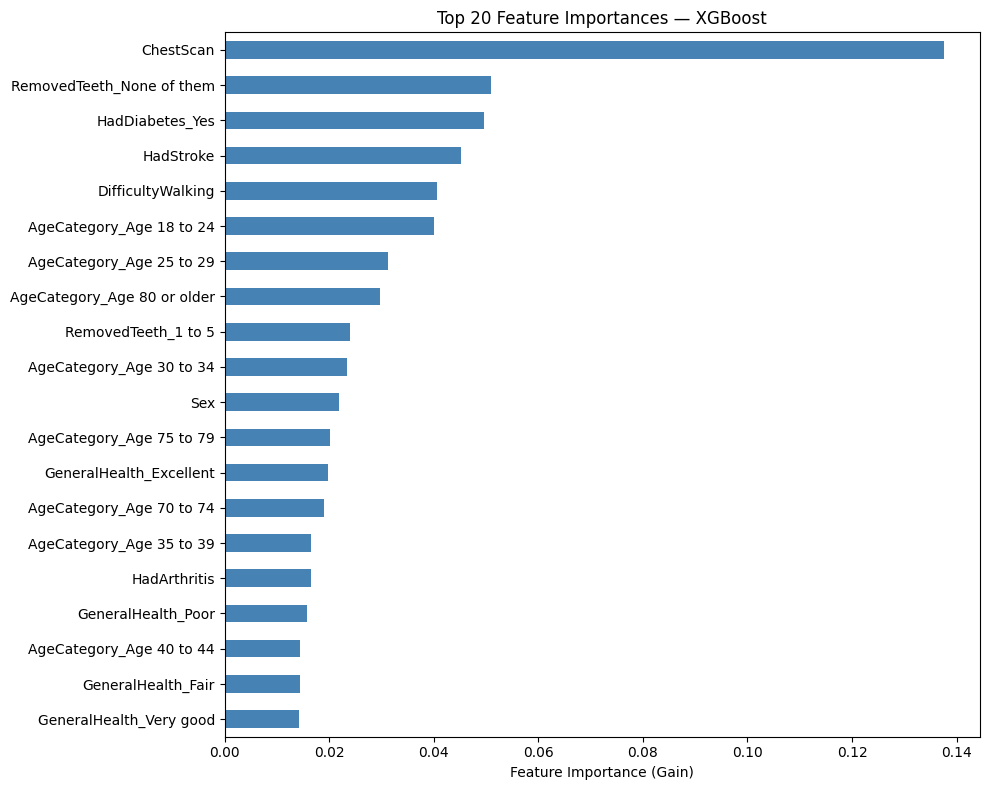

In [14]:
# Extract the XGBClassifier from the pipeline
xgb_model = best_pipeline.named_steps["xgb"]
importances = xgb_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(20).plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title("Top 20 Feature Importances — XGBoost")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Comparison Metrics Summary

Summary table for comparison against groupmates' models.

In [15]:
# Cross-validation metrics from the search
cv_results = pd.DataFrame(random_search.cv_results_)
best_idx = random_search.best_index_

mean_cv_f1 = cv_results.loc[best_idx, "mean_test_score"]
std_cv_f1 = cv_results.loc[best_idx, "std_test_score"]

# Test set metrics with custom threshold
test_accuracy = accuracy_score(y_test_enc, y_pred_custom)
test_f1_macro = f1_score(y_test_enc, y_pred_custom, average="macro")
test_f1_yes = f1_score(y_test_enc, y_pred_custom, average="binary")

summary = pd.DataFrame({
    "Model": ["XGBoost (tuned)"],
    "Best CV F1": [f"{mean_cv_f1:.4f} ± {std_cv_f1:.4f}"],
    "Test Accuracy": [f"{test_accuracy:.4f}"],
    "Test F1 (Macro)": [f"{test_f1_macro:.4f}"],
    "Test F1 (Yes)": [f"{test_f1_yes:.4f}"],
    "ROC-AUC": [f"{roc_auc:.4f}"],
    "Threshold": [THRESHOLD],
    "Best Params": [str(random_search.best_params_)],
})

print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
summary.T

MODEL COMPARISON SUMMARY


,0
Model,XGBoost (tuned)
Best CV F1,0.2735 ± 0.0025
Test Accuracy,0.8760
Test F1 (Macro),0.6130
Test F1 (Yes),0.2940
ROC-AUC,0.8213
Threshold,0.65
Best Params,"{'xgb__n_estimators': 400, 'xgb__max_depth': 1..."


## 10. Champion Model Defense — Threshold Optimization Experiment

To defend the choice of decision threshold, we run a 3-step experiment:
1. **Precision-Recall Curve** — visualise the trade-off between precision and recall
2. **Threshold Search** — sweep thresholds from 0.10 to 0.90 and compute F1, Precision, Recall at each
3. **Optimal F1 Analysis** — identify the mathematically optimal threshold and compare it to our chosen 0.65

### 10.1 Precision-Recall Curve

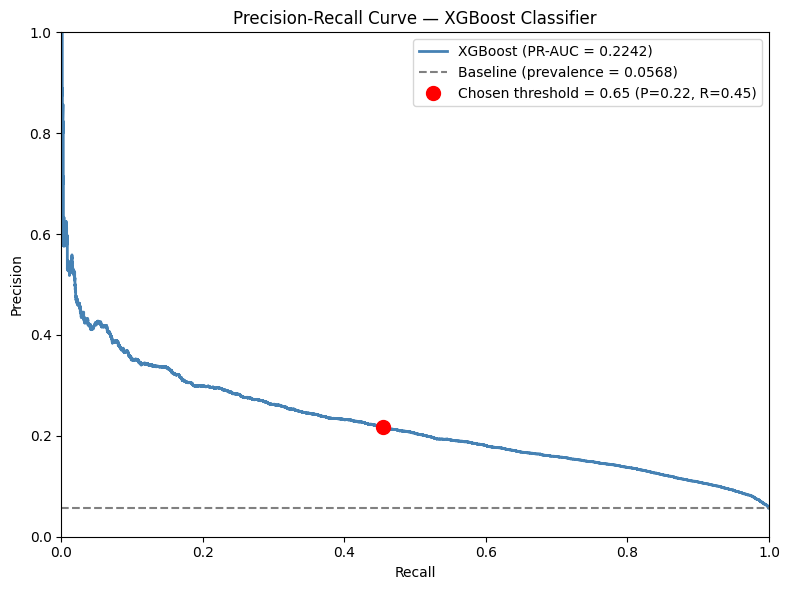

PR-AUC Score: 0.2242


In [16]:
from sklearn.metrics import precision_recall_curve, auc, precision_score, recall_score

precisions, recalls, pr_thresholds = precision_recall_curve(y_test_enc, y_proba)
pr_auc = auc(recalls, precisions)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recalls, precisions, color="steelblue", linewidth=2,
        label=f"XGBoost (PR-AUC = {pr_auc:.4f})")
ax.axhline(y=np.mean(y_test_enc), color="grey", linestyle="--",
           label=f"Baseline (prevalence = {np.mean(y_test_enc):.4f})")

# Mark the chosen threshold (0.65) on the curve
idx_065 = np.argmin(np.abs(pr_thresholds - 0.65))
ax.plot(recalls[idx_065], precisions[idx_065], "ro", markersize=10,
        label=f"Chosen threshold = 0.65 (P={precisions[idx_065]:.2f}, R={recalls[idx_065]:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — XGBoost Classifier")
ax.legend(loc="upper right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

print(f"PR-AUC Score: {pr_auc:.4f}")

### 10.2 Threshold Search (0.10 – 0.90)

Threshold Search Results
 Threshold     F1  Precision  Recall
    0.1000 0.1608     0.0878  0.9594
    0.1500 0.1777     0.0982  0.9327
    0.2000 0.1928     0.1079  0.9020
    0.2500 0.2071     0.1176  0.8672
    0.3000 0.2220     0.1281  0.8337
    0.3500 0.2356     0.1382  0.7971
    0.4000 0.2476     0.1481  0.7535
    0.4500 0.2587     0.1586  0.7015
    0.5000 0.2677     0.1689  0.6456
    0.5500 0.2798     0.1834  0.5906
    0.6000 0.2868     0.1976  0.5231
    0.6500 0.2940     0.2173  0.4548
    0.7000 0.2902     0.2367  0.3751
    0.7500 0.2777     0.2671  0.2891
    0.8000 0.2329     0.2990  0.1908
    0.8500 0.1618     0.3508  0.1051
    0.9000 0.0692     0.4295  0.0376


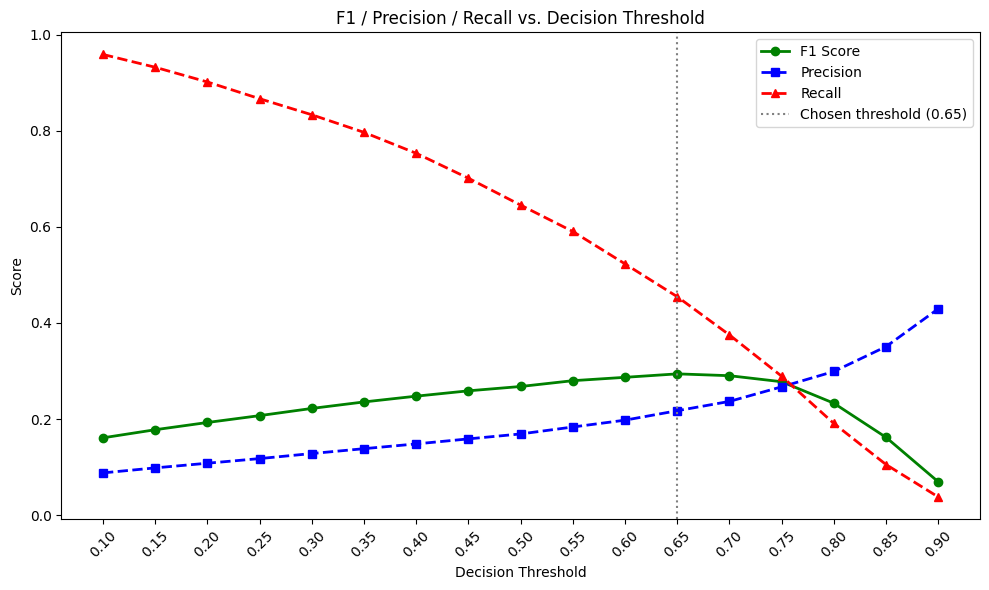

In [17]:
# Sweep thresholds from 0.10 to 0.90 in steps of 0.05
thresholds_sweep = np.arange(0.10, 0.91, 0.05)

results = []
for t in thresholds_sweep:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test_enc, y_pred_t, zero_division=0)
    prec = precision_score(y_test_enc, y_pred_t, zero_division=0)
    rec = recall_score(y_test_enc, y_pred_t, zero_division=0)
    results.append({"Threshold": round(t, 2), "F1": f1, "Precision": prec, "Recall": rec})

threshold_df = pd.DataFrame(results)

print("Threshold Search Results")
print("=" * 60)
print(threshold_df.to_string(index=False, float_format="{:.4f}".format))

# Plot F1, Precision, Recall vs Threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df["Threshold"], threshold_df["F1"], "o-", color="green", linewidth=2, label="F1 Score")
ax.plot(threshold_df["Threshold"], threshold_df["Precision"], "s--", color="blue", linewidth=2, label="Precision")
ax.plot(threshold_df["Threshold"], threshold_df["Recall"], "^--", color="red", linewidth=2, label="Recall")
ax.axvline(0.65, color="grey", linestyle=":", linewidth=1.5, label="Chosen threshold (0.65)")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("F1 / Precision / Recall vs. Decision Threshold")
ax.legend()
ax.set_xticks(thresholds_sweep)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 10.3 Optimal F1 Threshold vs. Chosen Threshold (0.65)

In [18]:
# Find the optimal threshold that maximises F1
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
optimal_threshold = best_row["Threshold"]
optimal_f1 = best_row["F1"]
optimal_prec = best_row["Precision"]
optimal_rec = best_row["Recall"]

# Metrics at the chosen 0.65 threshold
chosen_row = threshold_df[threshold_df["Threshold"] == 0.65].iloc[0]
chosen_f1 = chosen_row["F1"]
chosen_prec = chosen_row["Precision"]
chosen_rec = chosen_row["Recall"]

print("=" * 70)
print("OPTIMAL F1 THRESHOLD vs. CHOSEN THRESHOLD COMPARISON")
print("=" * 70)
print(f"\n{'Metric':<20} {'Optimal (t={optimal_threshold:.2f})':<25} {'Chosen (t=0.65)':<25}")
print("-" * 70)
print(f"{'F1 Score':<20} {optimal_f1:<25.4f} {chosen_f1:<25.4f}")
print(f"{'Precision':<20} {optimal_prec:<25.4f} {chosen_prec:<25.4f}")
print(f"{'Recall':<20} {optimal_rec:<25.4f} {chosen_rec:<25.4f}")

print(f"\n--- Trade-off Analysis ---")
f1_diff = chosen_f1 - optimal_f1
prec_diff = chosen_prec - optimal_prec
rec_diff = chosen_rec - optimal_rec

print(f"By choosing 0.65 over the optimal {optimal_threshold:.2f}:")
print(f"  F1 change:        {f1_diff:+.4f} ({'gained' if f1_diff > 0 else 'sacrificed'} {abs(f1_diff):.4f})")
print(f"  Precision change: {prec_diff:+.4f} ({'gained' if prec_diff > 0 else 'sacrificed'} {abs(prec_diff):.4f})")
print(f"  Recall change:    {rec_diff:+.4f} ({'gained' if rec_diff > 0 else 'sacrificed'} {abs(rec_diff):.4f})")

if chosen_prec > optimal_prec and chosen_rec < optimal_rec:
    print(f"\nConclusion: Threshold 0.65 trades {abs(rec_diff):.4f} Recall for "
          f"{abs(prec_diff):.4f} extra Precision compared to the F1-optimal threshold.")
    print("This is a deliberate policy choice — flagging only high-confidence cases to reduce false alarms.")

OPTIMAL F1 THRESHOLD vs. CHOSEN THRESHOLD COMPARISON

Metric               Optimal (t={optimal_threshold:.2f}) Chosen (t=0.65)          
----------------------------------------------------------------------
F1 Score             0.2940                    0.2940                   
Precision            0.2173                    0.2173                   
Recall               0.4548                    0.4548                   

--- Trade-off Analysis ---
By choosing 0.65 over the optimal 0.65:
  F1 change:        +0.0000 (sacrificed 0.0000)
  Precision change: +0.0000 (sacrificed 0.0000)
  Recall change:    +0.0000 (sacrificed 0.0000)
